In [73]:
import pandas as pd

df = pd.read_csv("churn_data.csv")

df.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   str    
 3   Contract          7043 non-null   str    
 4   PaperlessBilling  7043 non-null   str    
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
 8   Churn             7043 non-null   str    
dtypes: float64(1), int64(1), str(7)
memory usage: 495.3 KB


In [75]:
df.isnull().sum()

customerID          0
tenure              0
PhoneService        0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [76]:
df_duplicates = df.duplicated().sum()
print(df_duplicates)

if (df_duplicates > 0):

    df = df.drop_duplicates().reset_index(drop=True)

0


In [77]:
df.describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [78]:
df.head(250)

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...
245,0221-WMXNQ,4,Yes,Month-to-month,No,Electronic check,75.35,273.4,No
246,0303-UNCIP,41,Yes,One year,No,Mailed check,65.00,2531.8,No
247,9947-OTFQU,15,Yes,Month-to-month,Yes,Electronic check,74.40,1074.3,Yes
248,0322-YINQP,1,Yes,Month-to-month,Yes,Mailed check,48.55,48.55,Yes


In [79]:
varlist = ['PhoneService', 'PaperlessBilling', 'Churn']

def binary_map(x):

    return x.map({"Yes": 1, "No": 0})

df[varlist] = df[varlist].apply(binary_map)


In [80]:
df.head(250)

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,34,1,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,2,1,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,45,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,2,1,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...
245,0221-WMXNQ,4,1,Month-to-month,0,Electronic check,75.35,273.4,0
246,0303-UNCIP,41,1,One year,0,Mailed check,65.00,2531.8,0
247,9947-OTFQU,15,1,Month-to-month,1,Electronic check,74.40,1074.3,1
248,0322-YINQP,1,1,Month-to-month,1,Mailed check,48.55,48.55,1


In [81]:
category = ["Contract", "PaymentMethod"]

for col in category:

    print(f"{col} : {df[col].nunique()} Categories")

Contract : 3 Categories
PaymentMethod : 4 Categories


In [82]:
dummy1 = pd.get_dummies(df[["Contract", "PaymentMethod"]], drop_first=True, dtype=int)

df = pd.concat([df, dummy1], axis=1)

In [84]:
df.head(100)

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,0,Month-to-month,1,Electronic check,29.85,29.85,0,0,0,0,1,0
1,5575-GNVDE,34,1,One year,0,Mailed check,56.95,1889.5,0,1,0,0,0,1
2,3668-QPYBK,2,1,Month-to-month,1,Mailed check,53.85,108.15,1,0,0,0,0,1
3,7795-CFOCW,45,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,1,0,0,0,0
4,9237-HQITU,2,1,Month-to-month,1,Electronic check,70.70,151.65,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,8637-XJIVR,12,1,Month-to-month,1,Electronic check,78.95,927.35,1,0,0,0,1,0
96,9803-FTJCG,71,1,One year,1,Credit card (automatic),66.85,4748.7,0,1,0,1,0,0
97,0278-YXOOG,5,1,Month-to-month,0,Mailed check,21.05,113.85,1,0,0,0,0,1
98,3212-KXOCR,52,1,Two year,0,Bank transfer (automatic),21.00,1107.2,0,0,1,0,0,0


In [85]:
df = df.drop(['Contract','PaymentMethod'], axis=1)

In [86]:
df.head(100)

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,0,0,1,0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,1,0,0,0,1
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,0,1
3,7795-CFOCW,45,0,0,42.30,1840.75,0,1,0,0,0,0
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,8637-XJIVR,12,1,1,78.95,927.35,1,0,0,0,1,0
96,9803-FTJCG,71,1,1,66.85,4748.7,0,1,0,1,0,0
97,0278-YXOOG,5,1,0,21.05,113.85,1,0,0,0,0,1
98,3212-KXOCR,52,1,0,21.00,1107.2,0,0,1,0,0,0


In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   str    
 1   tenure                                 7043 non-null   int64  
 2   PhoneService                           7043 non-null   int64  
 3   PaperlessBilling                       7043 non-null   int64  
 4   MonthlyCharges                         7043 non-null   float64
 5   TotalCharges                           7043 non-null   str    
 6   Churn                                  7043 non-null   int64  
 7   Contract_One year                      7043 non-null   int64  
 8   Contract_Two year                      7043 non-null   int64  
 9   PaymentMethod_Credit card (automatic)  7043 non-null   int64  
 10  PaymentMethod_Electronic check         7043 non-null   int64  
 11  PaymentMethod_M

In [88]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   str    
 1   tenure                                 7043 non-null   int64  
 2   PhoneService                           7043 non-null   int64  
 3   PaperlessBilling                       7043 non-null   int64  
 4   MonthlyCharges                         7043 non-null   float64
 5   TotalCharges                           7032 non-null   float64
 6   Churn                                  7043 non-null   int64  
 7   Contract_One year                      7043 non-null   int64  
 8   Contract_Two year                      7043 non-null   int64  
 9   PaymentMethod_Credit card (automatic)  7043 non-null   int64  
 10  PaymentMethod_Electronic check         7043 non-null   int64  
 11  PaymentMethod_M

In [90]:
num_df = df[["tenure", "MonthlyCharges", "TotalCharges"]]


In [91]:
num_df.describe(percentiles=[0.25, .5, .75, .90, .95, .99])

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
90%,69.000000,102.600000,5976.640000
95%,72.000000,107.400000,6923.590000
99%,72.000000,114.729000,8039.883000


In [92]:
df.isnull().sum()

customerID                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
Contract_One year                         0
Contract_Two year                         0
PaymentMethod_Credit card (automatic)     0
PaymentMethod_Electronic check            0
PaymentMethod_Mailed check                0
dtype: int64

In [93]:
round(100*(df.isnull().sum()/len(df)), 2)

customerID                               0.00
tenure                                   0.00
PhoneService                             0.00
PaperlessBilling                         0.00
MonthlyCharges                           0.00
TotalCharges                             0.16
Churn                                    0.00
Contract_One year                        0.00
Contract_Two year                        0.00
PaymentMethod_Credit card (automatic)    0.00
PaymentMethod_Electronic check           0.00
PaymentMethod_Mailed check               0.00
dtype: float64

In [94]:
df = df[df["TotalCharges"].notnull()]

In [95]:
round(100*(df.isnull().sum()/len(df)), 2)

customerID                               0.0
tenure                                   0.0
PhoneService                             0.0
PaperlessBilling                         0.0
MonthlyCharges                           0.0
TotalCharges                             0.0
Churn                                    0.0
Contract_One year                        0.0
Contract_Two year                        0.0
PaymentMethod_Credit card (automatic)    0.0
PaymentMethod_Electronic check           0.0
PaymentMethod_Mailed check               0.0
dtype: float64

In [97]:
from sklearn.model_selection import train_test_split

In [98]:
x = df.drop(["customerID", "Churn"], axis=1)

x.head()

,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,29.85,29.85,0,0,0,1,0
1,34,1,0,56.95,1889.50,1,0,0,0,1
2,2,1,1,53.85,108.15,0,0,0,0,1
3,45,0,0,42.30,1840.75,1,0,0,0,0
4,2,1,1,70.70,151.65,0,0,0,1,0


In [99]:
y = df["Churn"]

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [100]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=100)


In [101]:
from sklearn.preprocessing import StandardScaler

In [114]:
scaler = StandardScaler()

x_train[["tenure", "MonthlyCharges", "TotalCharges"]] = scaler.fit_transform(x_train[["tenure", "MonthlyCharges", "TotalCharges"]])
x_test[['tenure','MonthlyCharges','TotalCharges']] = scaler.transform(x_test[['tenure','MonthlyCharges','TotalCharges']])

x_train.head()

,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
879,0.019693,1,1,-0.338074,-0.276449,0,0,0,0,0
5790,0.305384,0,1,-0.464443,-0.112702,0,0,0,1,0
6498,-1.286319,1,1,0.581425,-0.974430,0,0,0,1,0
880,-0.919003,1,1,1.505913,-0.550676,0,0,0,1,0
2784,-1.163880,1,1,1.106854,-0.835971,0,0,0,0,0


In [115]:
import numpy as np


print("Mean:\n", x_train[['tenure', 'MonthlyCharges', 'TotalCharges']].mean())  
print("Standard Deviation:\n", x_train[['tenure', 'MonthlyCharges', 'TotalCharges']].std())  


Mean:
 tenure            2.742851e-17
MonthlyCharges    1.443606e-17
TotalCharges     -1.010524e-17
dtype: float64
Standard Deviation:
 tenure            1.000102
MonthlyCharges    1.000102
TotalCharges      1.000102
dtype: float64


In [116]:
churn = (sum(df['Churn'])/len(df['Churn']))*100
churn

26.578498293515356

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

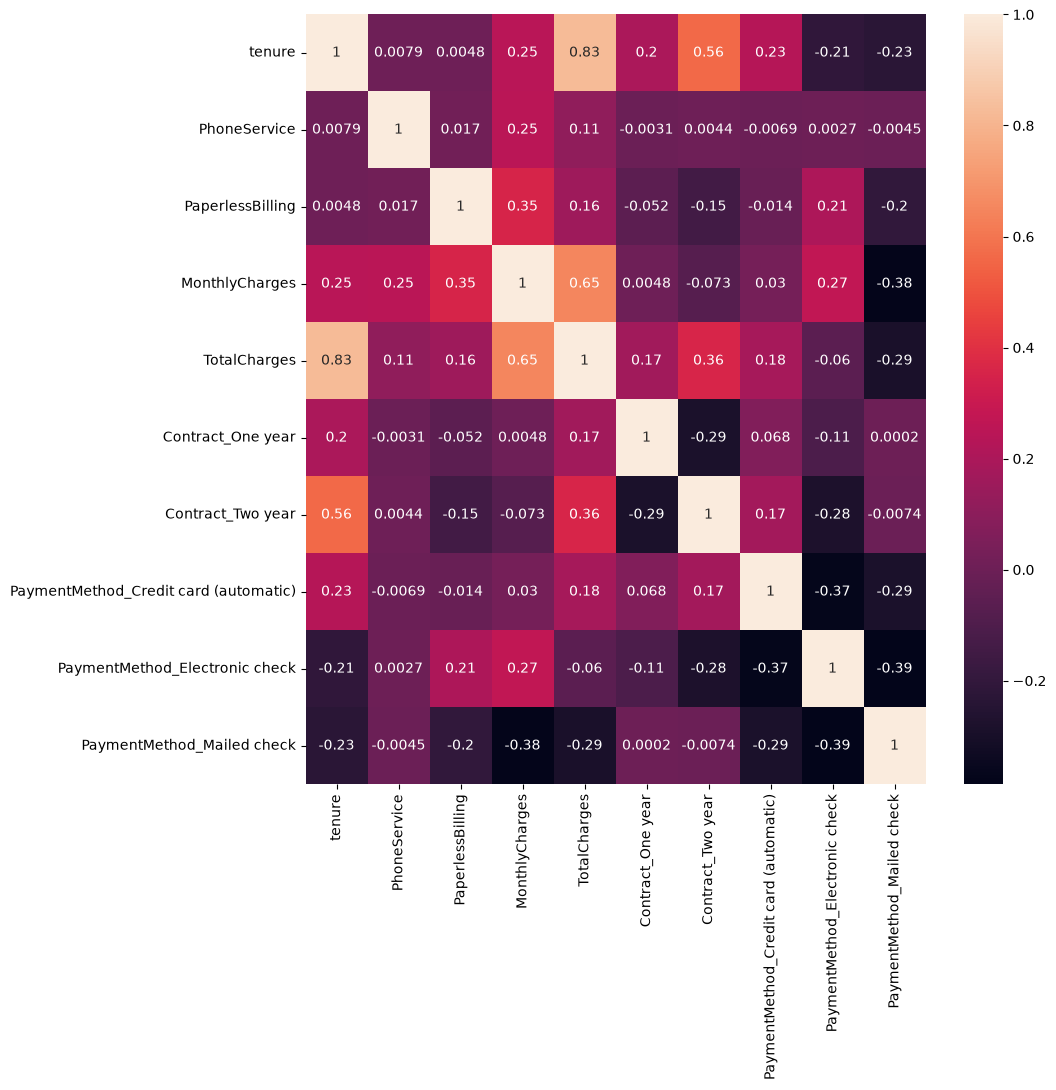

In [118]:
plt.figure(figsize=(10,10))
sns.heatmap(x.corr(), annot=True)
plt.show()

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

reg = LogisticRegression()
reg.fit(x_train, y_train)

y_pred = reg.predict(x_test)

print(f"Logistic Regression model accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Logistic Regression model precision: {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Logistic Regression model recall: {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"Logistic Regression model F1 score: {f1_score(y_test, y_pred) * 100:.2f}%")

confusion = confusion_matrix(y_test, y_pred)
print(confusion)

Logistic Regression model accuracy: 27.58%
Logistic Regression model precision: 27.58%
Logistic Regression model recall: 100.00%
Logistic Regression model F1 score: 43.24%
[[   0 1528]
 [   0  582]]
